In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Load utility functions from detect_clusters.py
import detect_clusters
import matplotlib.pyplot as plt

In [3]:
import skimage
from skimage.io import imread
from skimage.measure import regionprops
import numpy as np
import math
from os.path import join
import pandas as pd
import os
from os.path import join
from pathlib import Path

In [4]:
from detect_clusters import track_cells, matchClusters, detectAndTrackClusters, generate_graph
from pathlib import Path
import os
from skimage.io import imsave
from detect_clusters import computeVelocities, computeRelativeVelocities
from detect_clusters import EdgeFilterAngleCountVelocity
from detect_clusters import labels2rgb, rag_attribute_image, show_rag2
from detect_clusters import rag_velocity_image, vel2rgb
from detect_clusters import to_pandas_nodelist
from detect_clusters import loadDPTracks, EdgeFilterNone

In [5]:
DATADIR = Path('../data/')

## New dataset June 18

In [352]:
from detect_clusters import load_multiframe_labels
from detect_clusters import compute_labelimages_df
from detect_clusters import show_label_df

# COMPUTE SPOTS OURSELVES

# Load image stack as volume (nbframes, height, width)
LL = load_multiframe_labels(DATADIR / 'labelimages.tif')

# Compute dataframe of regions
ldf = compute_labelimages_df(LL)

100%|██████████| 50/50 [00:02<00:00, 22.30it/s]


<Axes: >

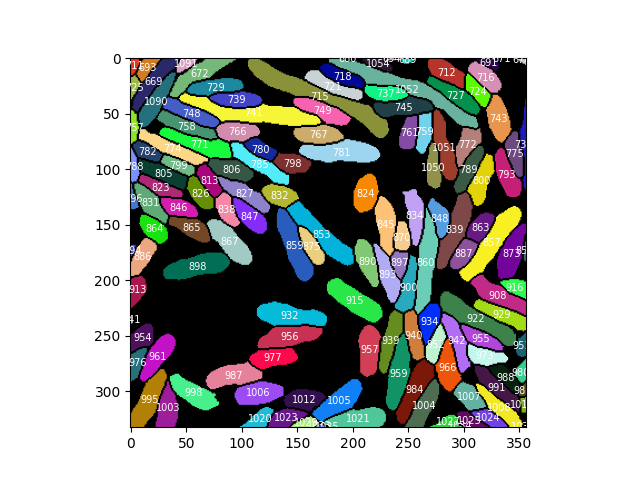

In [353]:
# Show one frame
# plt.figure()
# L = LL[0]
# plt.imshow(labels2rgb( L ));

from detect_clusters import show_label_df

show_label_df(LL, ldf, frame=2,  node_id='label', node_id_color='white', node_id_fontsize=7, ax=None)
#show_label_df(LL, ldf, frame=2, marker='+', markercolor='red', ax=None)

# Show two frames overlayed
# ax = show_label_df(LL, ldf, frame=0, marker='+', markercolor='red', ax=None)
# show_label_df(None, ldf, frame=1, marker='+', markercolor='orange', ax=ax)


In [359]:
#df0 = pd.read_csv(DATADIR / 'original_spotswithedits.csv', header=0, skiprows=[1,2,3], )
df0 = pd.read_csv(DATADIR / 'original_spots.csv', header=0, skiprows=[1,2,3], )


# Clean up
df = df0[['TRACK_ID','FRAME','POSITION_X','POSITION_Y','ID']]
df = df0.rename(columns = {'TRACK_ID':  'trackid',
                           'FRAME':     'frame',
                           'POSITION_X':'cx',
                           'POSITION_Y':'cy',
                           'ID':        'spotid'})
df = df[['frame','cx','cy','spotid','trackid']]
df = df.sort_values(['frame','trackid'])

display(df0)
display(df)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,ELLIPSE_Y0,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,PERIMETER,CIRCULARITY,SOLIDITY,SHAPE_INDEX
0,ID119585,119585,0,107.0,352.179245,73.407233,0.0,16.0,16,5.808687,...,1.407233,9.778075,5.404709,1.224318,1.809177,106.0,46.834957,0.607261,0.933921,4.549013
1,ID117760,117760,0,650.0,330.952729,55.093133,0.0,2.0,2,14.389600,...,-0.037908,21.857133,9.825987,1.348738,2.224421,650.5,107.339020,0.709483,0.958027,4.208564
2,ID118757,118757,0,842.0,335.298028,74.017160,0.0,13.0,13,16.400361,...,-0.041439,27.121954,11.158362,-0.130749,2.430640,845.0,121.703463,0.716904,0.938368,4.186726
3,ID118148,118148,0,360.0,344.978502,66.694637,0.0,8.0,8,10.712176,...,-0.410095,15.206499,8.523781,2.555069,1.784009,360.5,76.553587,0.773008,0.967785,4.031929
4,ID118820,118820,0,257.0,347.855943,69.562016,0.0,14.0,14,9.062227,...,0.587641,12.703563,8.906698,0.266333,1.426293,258.0,63.528557,0.803326,0.977273,3.955115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6339,ID122701,122701,518,43.0,0.182171,104.670543,0.0,44.0,44,3.699639,...,-0.154033,6.975762,2.329217,1.548454,2.994896,43.0,34.180340,0.462515,0.905263,5.212453
6340,ID123023,123023,518,53.0,0.326923,114.105769,0.0,45.0,45,4.068429,...,-0.349486,7.754009,2.766620,-1.532486,2.802701,52.0,36.953369,0.478526,0.928571,5.124510
6341,ID117683,117683,521,427.0,341.581282,301.605119,0.0,0.0,0,11.651574,...,1.416159,20.569340,8.222761,0.581160,2.501513,426.5,95.061477,0.593089,0.875770,4.603043
6342,ID117685,117685,521,579.0,339.278947,303.172807,0.0,1.0,1,13.469842,...,0.361012,24.917820,7.791384,0.768596,3.198125,570.0,112.580387,0.565144,0.930612,4.715474


,frame,cx,cy,spotid,trackid
8,0,322.166667,43.691540,117670,0
23,0,268.879619,254.695595,117415,1
88,0,239.949052,238.205239,117334,5
99,0,24.502481,326.756410,117772,6
134,0,126.896579,104.277403,116925,7
...,...,...,...,...,...
6321,49,302.337070,137.655456,123068,509
6329,49,190.500000,-0.305556,123155,514
6331,49,328.539325,309.916609,123200,515
6333,49,34.603098,11.132917,123154,516


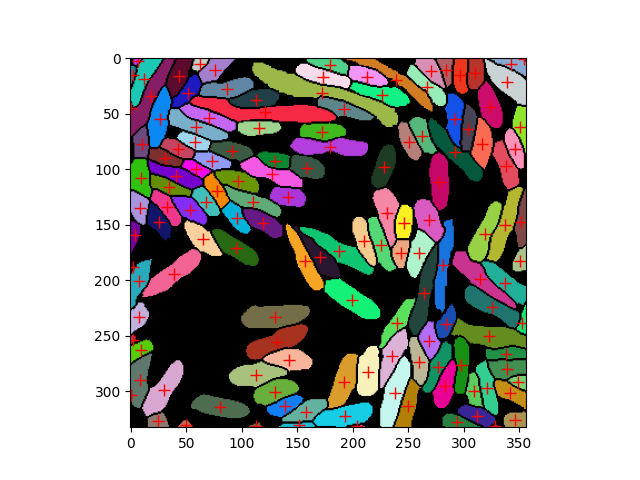

In [228]:
frame = 0

# Compare both
#ax = show_label_df(LL, ldf, frame=frame, node_id='label', ax=None)  # Label image spots
ax = show_label_df(LL, ldf, frame=frame, marker='+', markercolor='red', markersize=9, ax=None)  # Label image spots
#show_label_df(None, df, frame=frame, marker='x', markercolor='blue', ax=ax)      # Trackmate spots

In [363]:
from detect_clusters import match_df_to_labeldf
df1, df2 = match_df_to_labeldf(ldf, df, thresh=10.0)
dfm = pd.merge(df1,df2,how='outer', on=['frame','spotid','trackid','label','match_d'], suffixes=('_TM','')) # TrackMate vs LaBel
# Fill in missing cx,cy from TrackMate
dfm.loc[dfm.label.isna(),['cx','cy']] = dfm.loc[dfm.label.isna(),['cx_TM','cy_TM']]

dfm

100%|██████████| 50/50 [00:00<00:00, 120.74it/s]

Matched label: 6333
Matched trackmate: 6333  (should be equal to previous)
Unmatched label: 191
Unmatched trackmate: 11


,frame,cx_TM,cy_TM,spotid,trackid,match_loc2,label,match_d,cx,cy,area,orientation,match_loc1
0,0,114.967342,63.073574,116766.0,44.0,34.0,770.0,0.069061,115.033408,63.053452,449.0,-1.530493,662.0
1,0,250.779441,75.789820,116774.0,40.0,35.0,772.0,0.110437,250.766110,75.680191,419.0,0.425947,563.0
2,0,172.424505,66.500913,116782.0,47.0,36.0,773.0,0.114099,172.400366,66.389397,547.0,1.556235,732.0
3,0,10.028653,77.106017,116787.0,169.0,37.0,775.0,0.118730,9.988539,77.217765,349.0,-0.027123,2726.0
4,0,345.823173,81.981438,116793.0,107.0,38.0,778.0,0.158515,345.704918,81.875878,427.0,0.332687,1881.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6530,49,NaN,NaN,NaN,NaN,NaN,855.0,NaN,352.402299,196.517241,87.0,0.173654,NaN
6531,49,NaN,NaN,NaN,NaN,NaN,869.0,NaN,49.818650,272.733762,1555.0,-0.180515,NaN
6532,49,NaN,NaN,NaN,NaN,NaN,892.0,NaN,155.485677,241.457031,768.0,-1.401262,NaN
6533,49,NaN,NaN,NaN,NaN,NaN,923.0,NaN,353.542373,269.271186,59.0,0.134334,NaN


In [362]:
# Merge
dfm = pd.merge(df1,df2,how='outer', on=['frame','spotid','trackid','label','match_d'], suffixes=('_TM','')) # TrackMate vs LaBel
dfm[dfm.frame==22]

dfm_nomatch = dfm[dfm.label.isna() | dfm.spotid.isna()]
dfm_nomatch[dfm_nomatch.frame==22]

,frame,cx_TM,cy_TM,spotid,trackid,match_loc2,label,match_d,cx,cy,area,orientation,match_loc1
2992,22,202.257576,-0.762626,119171.0,227.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3042,22,283.559574,124.301418,119537.0,289.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3074,22,NaN,NaN,NaN,NaN,NaN,797.0,NaN,4.238938,187.982301,452.0,-0.014689,NaN
3075,22,NaN,NaN,NaN,NaN,NaN,828.0,NaN,1.377358,240.150943,53.0,0.103180,NaN
3076,22,NaN,NaN,NaN,NaN,NaN,904.0,NaN,0.000000,306.000000,1.0,-0.785398,NaN
3077,22,NaN,NaN,NaN,NaN,NaN,915.0,NaN,312.512931,326.782328,464.0,-1.535065,NaN
3078,22,NaN,NaN,NaN,NaN,NaN,991.0,NaN,271.337349,146.104418,249.0,1.239231,NaN


<Axes: >

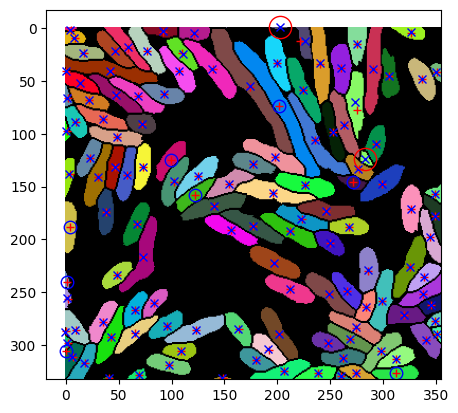

In [180]:
frame = 22

# Compare both, but show discrepencies with circles
ax = show_label_df(LL, ldf, frame=frame, marker='+', markercolor='red', ax=None)  # Label image spots
show_label_df(None, df, frame=frame, marker='x', markercolor='blue', ax=ax)      # Trackmate spots
show_label_df(None, df1[df1.label.isna()], frame=frame, marker='o', markercolor='red', markersize=16, ax=ax)      # Labels missing, centered on trackmate spot
show_label_df(None, df2[df2.spotid.isna()], frame=frame, marker='o', markercolor='blue', markersize=9, ax=ax)      # Trackmate missing, centered on centroid

In [9]:
ddf = df.sort_values(['trackid', 'frame']).reset_index()

# Group by track_id and compute the difference in frame number
ddf['frame_diff'] = ddf.groupby('trackid')['frame'].diff()

# Non-sequential frames will have a difference != 1 (excluding first row in each group which is NaN)
ddf_non_seq = ddf[ddf['frame_diff'].notna() & (ddf['frame_diff'] != 1)]

#with pd.option_context('display.max_rows', None):
#  display( pd.concat( [ddf.loc[ddf_non_seq.index],ddf.loc[ddf_non_seq.index-1],ddf.loc[ddf_non_seq.index+1],ddf.loc[ddf_non_seq.index-2]]).drop_duplicates().sort_values(['trackid', 'frame','index']) )

/tmp/ipykernel_13486/725285786.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,axes = plt.subplots(1,3,figsize=(s*3,s))


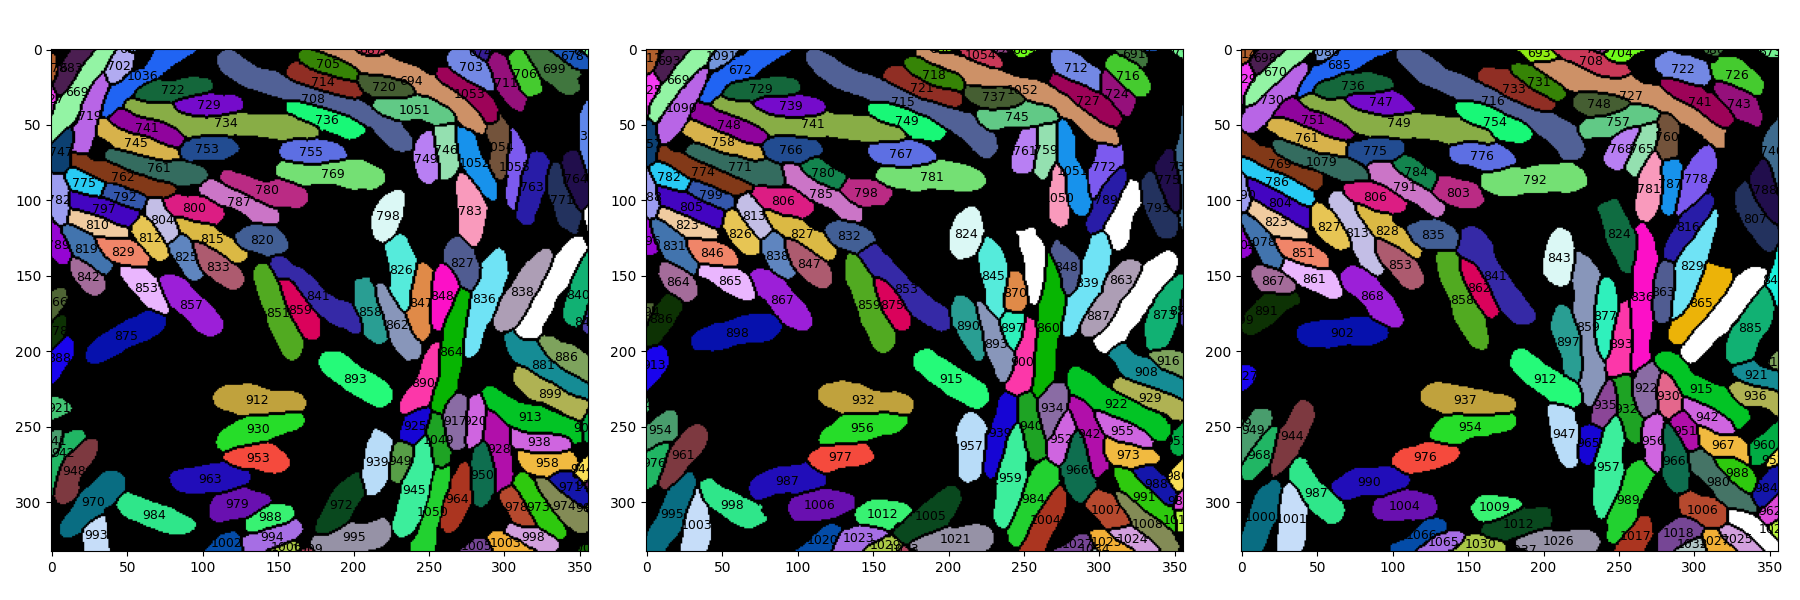

In [242]:
from detect_clusters import get_rgbmap

s=6
fig,axes = plt.subplots(1,3,figsize=(s*3,s))

frame1 = 1
frame2 = 2
frame3 = 3

labeltype='trackid'
idtype='label'

ax = axes[0]
ax = show_label_df(LL2, df1, frame=frame1, label_map=labeltype, node_id=idtype, marker=None, markercolor='red', markersize=9, ax=ax)  # Label image spots
#show_label_df(None, df2, frame=frame1, marker='x', markercolor='blue', ax=ax)      # Trackmate spots


ax = axes[1]
ax = show_label_df(LL2, df1, frame=frame2, label_map=labeltype, node_id=idtype, marker=None, markercolor='red', markersize=9, ax=ax)  # Label image spots
#show_label_df(None, df2, frame=frame2, marker='x', markercolor='blue', ax=ax)      # Trackmate spots


ax = axes[2]
ax = show_label_df(LL2, df1, frame=frame3, label_map=labeltype, node_id=idtype, marker=None, markercolor='red', markersize=9, ax=ax)  # Label image spots
#show_label_df(None, df2, frame=frame3, marker='x', markercolor='blue', ax=ax)      # Trackmate spots

fig.tight_layout()

# Background in black
# label with trackid as NA shown in white

In [238]:
LL2=LL.copy()

In [240]:
LL2[2,LL2[2,...]==887] = 863

In [236]:
df0[df0.ID==123154]

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,...,ELLIPSE_Y0,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,PERIMETER,CIRCULARITY,SOLIDITY,SHAPE_INDEX
6333,ID123154,123154,516,364.0,34.603098,11.132917,0.0,49.0,49,10.712176,...,-0.508147,15.194258,8.132738,1.585486,1.868283,360.5,75.959289,0.785151,0.956233,4.000629


In [211]:
from detect_clusters import xylim

In [ ]:
%matplotlib widget

from track_gui import FrameViewer

# ---- Use the class ----
viewer = FrameViewer(df1, LL)
viewer.display();


In [350]:
7 in set([1,3,4,5,6])

False

In [322]:
viewer.id_fontsize = 6
viewer.update_plot()

In [344]:
M = (viewer.LL2[2]==9000).copy()

In [347]:
viewer.LL2[2,M] = 915

In [264]:
def labelframetuple(row):
  frame = row['frame']
  label = row['label']
  if (not np.isnan(frame)): 
    frame=int(frame) 
  else: 
    frame=-1
  if (not np.isnan(label)): 
    label=int(label) 
  else: 
    label=-1
  return (label, frame)

sdf1 = df1[df1.apply(labelframetuple, axis=1).isin(selected)]
sdf1

,frame,cx,cy,spotid,trackid,match_loc2,label,match_d
134,0,126.896579,104.277403,116925,7,49.0,807.0,0.061702
2213,0,129.623089,232.812372,117370,124,91.0,933.0,0.172577


In [252]:
df

,frame,cx,cy,spotid,trackid
8,0,322.166667,43.691540,117670,0
23,0,268.879619,254.695595,117415,1
88,0,239.949052,238.205239,117334,5
99,0,24.502481,326.756410,117772,6
134,0,126.896579,104.277403,116925,7
...,...,...,...,...,...
6321,49,302.337070,137.655456,123068,509
6329,49,190.500000,-0.305556,123155,514
6331,49,328.539325,309.916609,123200,515
6333,49,34.603098,11.132917,123154,516


### Plotting multiple frames with consistent color

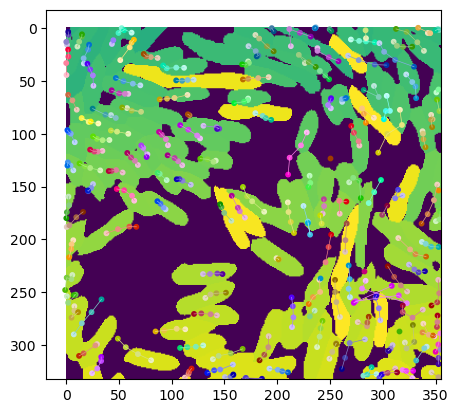

In [11]:
from detect_clusters import get_rgbmap


# Interval to show
frame0=0
frame1=3

plt.imshow( img[frame0] )

cols = get_rgbmap(df.trackid.unique())

for trackid in df.trackid.unique():
  track = df[ (df.trackid==trackid) & (df.frame>=frame0) & (df.frame<=frame1) ]
  alpha = (np.array((track.frame-frame0)/(frame1-frame0))*0.75+0.25).reshape(-1,1)  # Get a sense of time
  plt.plot( track.cx, track.cy, '-', color=cols[trackid] *0.5 + 0.5, linewidth=0.5 )
  plt.scatter( track.cx, track.cy, 10, cols[trackid,:] * alpha + (1-alpha) )
#plt.xlim(0,350)
#plt.ylim(350,0)

In [80]:
from skimage.measure import regionprops_table
df2 = regionprops_table(L_array[0], properties=['label','centroid','area','orientation'])
df2 = pd.DataFrame(df2)

df2 = df2[df2['label'] != 0].reset_index(drop=True)  # Drop background

df2 = df2.rename(columns={'centroid-0':'cy','centroid-1':'cx'})

df2

,label,cy,cx,area,orientation
0,666,10.286976,75.693157,453.0,-0.924415
1,678,5.165563,62.099338,151.0,-0.983067
2,681,2.693878,6.346939,49.0,-0.917262
3,686,34.421548,17.799163,956.0,-0.478278
4,693,19.865885,238.833333,768.0,1.014758
...,...,...,...,...,...
134,1060,211.840982,264.243330,937.0,-0.232595
135,1061,273.308140,259.453488,516.0,0.184759
136,1062,276.400000,297.638261,575.0,-0.016425
137,1063,84.788183,291.548495,897.0,0.755877


In [107]:
from detect_clusters import match_df_to_labelimages

df, ldf = match_df_to_labelimages(L_array, df, thresh = 3.0, next_id=None)


Processing frame 0
Processing frame 1
Processing frame 2
Processing frame 3
Processing frame 4
Processing frame 5
Processing frame 6
Processing frame 7
Processing frame 8
Processing frame 9
Processing frame 10
Processing frame 11
Processing frame 12
Processing frame 13
Processing frame 14
Processing frame 15
Processing frame 16
Processing frame 17
Processing frame 18
Processing frame 19
Processing frame 20
Processing frame 21
Processing frame 22
Processing frame 23
Processing frame 24
Processing frame 25
Processing frame 26
Processing frame 27
Processing frame 28
Processing frame 29
Processing frame 30
Processing frame 31
Processing frame 32
Processing frame 33
Processing frame 34
Processing frame 35
Processing frame 36
Processing frame 37
Processing frame 38
Processing frame 39
Processing frame 40
Processing frame 41
Processing frame 42
Processing frame 43
Processing frame 44
Processing frame 45
Processing frame 46
Processing frame 47
Processing frame 48
Processing frame 49


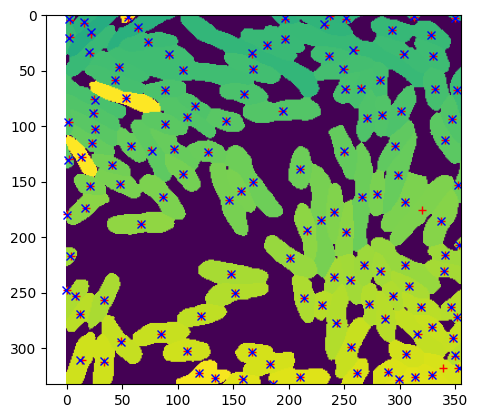

In [103]:
%matplotlib inline
frame=3
fdf = ldf[ldf.frame==frame]
fdf1 = df[df.frame==frame]

fig = plt.figure()
plt.imshow(L_array[frame])
plt.plot( fdf.cx, fdf.cy, 'r+' )

plt.plot( fdf1.cx, fdf1.cy, 'bx' )

In [108]:
ldf

,label,cy,cx,area,orientation,trackid,spotid,match_d,frame
0,666,10.286976,75.693157,453.0,-0.924415,NaN,NaN,NaN,0
1,678,5.165563,62.099338,151.0,-0.983067,NaN,NaN,1.041168,0
2,681,2.693878,6.346939,49.0,-0.917262,NaN,NaN,NaN,0
3,686,34.421548,17.799163,956.0,-0.478278,NaN,NaN,1.472084,0
4,693,19.865885,238.833333,768.0,1.014758,NaN,NaN,1.316592,0
...,...,...,...,...,...,...,...,...,...
6519,993,331.857143,24.142857,7.0,1.474599,NaN,NaN,0.310438,49
6520,1026,256.960396,24.446959,707.0,-1.009040,NaN,NaN,0.132064,49
6521,1027,137.401578,39.921893,2535.0,0.081539,NaN,NaN,NaN,49
6522,1063,321.750903,329.478339,554.0,-1.296386,NaN,NaN,0.103743,49


In [105]:
df[df.frame==0]

,trackid,frame,cx,cy,spotid,label,match_d
8,0,0,322.166667,43.691540,117670,708.0,True
23,1,0,268.879619,254.695595,117415,742.0,True
88,5,0,239.949052,238.205239,117334,927.0,True
99,6,0,24.502481,326.756410,117772,962.0,True
134,7,0,126.896579,104.277403,116925,1060.0,True
...,...,...,...,...,...,...,...
2747,176,0,346.131333,326.006000,117770,NaN,True
2749,177,0,235.433752,267.461878,117431,NaN,True
2750,178,0,284.076642,9.365572,117440,NaN,True
2753,179,0,43.358809,14.800491,117449,NaN,True


In [87]:
df.groupby('frame')['label'].count()

frame
0     5
1     7
2     8
3     7
4     7
5     8
6     6
7     7
8     7
9     6
10    6
11    5
12    5
13    5
14    4
15    4
16    4
17    4
18    3
19    2
20    2
21    1
22    1
23    2
24    1
25    2
26    2
27    2
28    1
29    2
30    1
31    2
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
Name: label, dtype: int64

### Use RAG for more complex display

In [60]:
df

,trackid,frame,cx,cy
8,0,0,322.166667,43.691540
23,1,0,268.879619,254.695595
88,5,0,239.949052,238.205239
99,6,0,24.502481,326.756410
134,7,0,126.896579,104.277403
...,...,...,...,...
6321,509,49,302.337070,137.655456
6329,514,49,190.500000,-0.305556
6331,515,49,328.539325,309.916609
6333,516,49,34.603098,11.132917


In [63]:
from detect_clusters import match_df_to_rag

frame1 = 0

L1 = np.array(img[frame1])
rag1 = generate_graph(L1)

df1, df2 = match_df_to_rag(rag1, df, frame1)

In [66]:
df1

,trackid,frame,cx,cy,spotid,detid
8,0,0,322.166667,43.691540,117670.0,NaN
-1,0,0,0.000000,0.000000,NaN,NaN
23,1,0,268.879619,254.695595,117415.0,NaN
88,5,0,239.949052,238.205239,117334.0,NaN
99,6,0,24.502481,326.756410,117772.0,NaN
...,...,...,...,...,...,...
2747,176,0,346.131333,326.006000,117770.0,NaN
2749,177,0,235.433752,267.461878,117431.0,NaN
2750,178,0,284.076642,9.365572,117440.0,NaN
2753,179,0,43.358809,14.800491,117449.0,NaN


Cell DPTrack match: matched = 128, unmatched=1, new = 12, map2to1[0] = 0


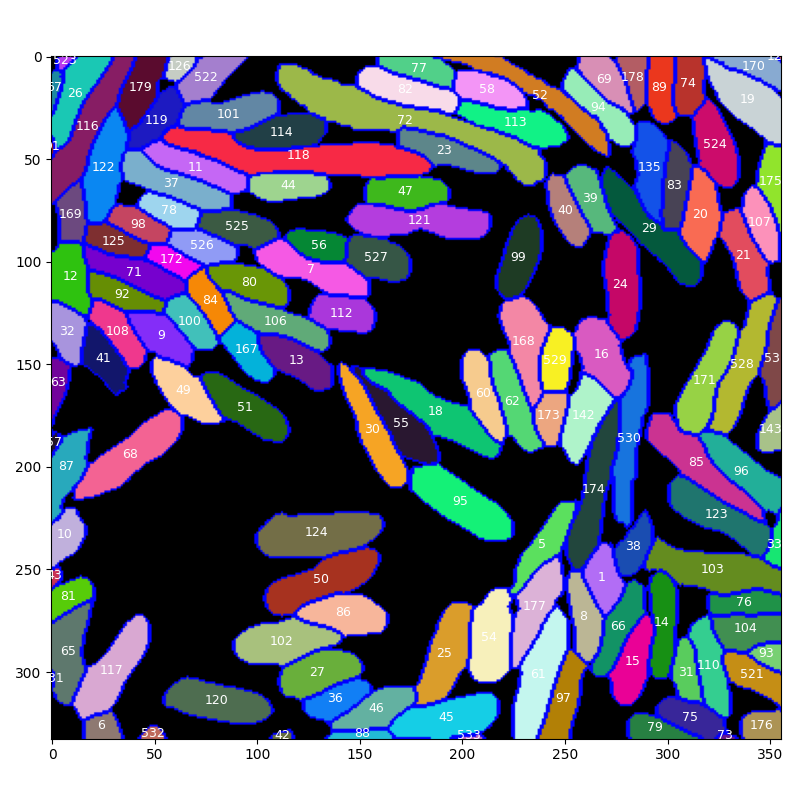

In [10]:
from detect_clusters import EdgeFilterAngleCountVelocity
from detect_clusters import rag_velocity_image, vel2rgb, show_rag2, EdgeFilterNone,xylim
from detect_clusters import generate_graph, trackidFromDPTrack, track_cells, detectAndTrackClusters
from detect_clusters import computeVelocities, computeAreaChange
from detect_clusters import labels2rgb, rag_attribute_image, rag_velocity_image
from skimage.io import imsave

edge_filter = EdgeFilterNone()


L1 = np.array(img[0])

rag1 = generate_graph(L1)

trackidFromDPTrack(rag1, df[df.frame==0])


L1rgb = labels2rgb(L1)

s = 8
fig,ax = plt.subplots(1,1,figsize=(s,s))
show_rag2(L1, rag1, L1rgb, img_cmap=None, ax=ax, border_color='blue', edge_width=3, edge_cmap='magma', 
          hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0,
          velocity_back=False, node_id='trackid', node_id_color='white')
#xylim(r)
plt.tight_layout()

In [ ]:
%matplotlib widget

frame1,frame2,frame3 = 0,1,2

trackid = 38
cx,cy = df[(df.frame==frame2)&(df.trackid==trackid)].iloc[0][['cx','cy']]
ww = 150
r = [cx-ww/2,cx+ww/2,cy+ww/2,cy-ww/2,]  # Caution: ylim requires decreasing ranges to keep top-left origin

s = 6
nx = 3
fig,axes = plt.subplots(1,nx,figsize=(nx*s,s))

selected = []

def update_plot():
  # Basic approach: just erase and redraw everything
  for ax in axes:
    ax.cla()

  ax=axes[0]
  plt.sca(ax)
  show_rag2(L1, rag1, K1rgb, img_cmap=None, ax=ax, border_color='blue', edge_width=1, edge_cmap='magma', 
            hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0,
            velocity_back=False, node_id='trackid', node_id_color='white')
  xylim(r)
  plt.title(f'Frame {frame1}')

  sdf1 = df[df[['trackid','frame']].isin(selected)]  # Selected list of tuples (id,frame)
  ax.plot( sdf1.cx, sdf1.cy, 'or', markersize=20, markerfacecolor='None' )

  ax=axes[1]
  plt.sca(ax)
  show_rag2(L2, rag2, K2rgb, img_cmap=None, ax=ax, border_color='blue', edge_width=1, edge_cmap='magma', 
            hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0,
            velocity_back=False, node_id='trackid', node_id_color='white')
  xylim(r)
  plt.title(f'Frame {frame2}')

  ax=axes[2]
  plt.sca(ax)
  show_rag2(L3, rag3, K3rgb, img_cmap=None, ax=ax, border_color='blue', edge_width=1, edge_cmap='magma', 
            hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0,
            velocity_back=False, node_id='trackid', node_id_color='white')
  xylim(r)
  plt.title(f'Frame {frame3}')

  plt.tight_layout()

glob = {}

def on_click(event):
  #axes[0].plot(240,200,'rx') # For testing than click is registered
  if (event.inaxes):
    #glob['event'] = event  # For debugging the event
    #print(f'Clicked at {event.xdata},{event.ydata}') # Doe snot work in VScode by default, would need an Ouput widget
    #axes[0].plot(event.xdata,event.ydata,'rx')
    if (event.inaxes not in axes):
      return
    ax_idx = axes.index(event.inaxes)
    frame = [frame0, frame1, frame2][ax_idx]
    
    x,y = round(event.xdata),round(event.ydata)
    detid = L1[y,x]
    trackid = K1[y,x]

    sel = (detid,frame)  # Use tuple to keep both id and frame and be hashable

    if ( sel not in selected):
      selected.append( sel )
    else:
      selected.remove( sel )
    update_plot()

update_plot()
fig.canvas.mpl_connect('button_press_event', on_click)


NameError: name 'trackidFromDPTrack' is not defined

In [56]:
rag2.nodes.data()

NodeDataView({0: {'labels': [0], 'id': 0, 'area': 0.0, 'angle': 0.0, 'centroid': array([500., 500.]), 'boundary_count': 14673, 'trackid': 0}, 669: {'labels': [669], 'id': 669, 'area': 878.0, 'angle': -0.5661599508724394, 'centroid': array([28.25398633, 17.65489749]), 'boundary_count': 346, 'trackid': 116}, 674: {'labels': [674], 'id': 674, 'area': 80.0, 'angle': 1.253783765978955, 'centroid': array([  2.875 , 284.8625]), 'boundary_count': 63, 'trackid': 178}, 678: {'labels': [678], 'id': 678, 'area': 233.0, 'angle': 1.161920768403382, 'centroid': array([  5.63948498, 344.7639485 ]), 'boundary_count': 101, 'trackid': 170}, 680: {'labels': [680], 'id': 680, 'area': 15.0, 'angle': 1.490302419909493, 'centroid': array([ 0.6, 52.8]), 'boundary_count': 26, 'trackid': 126}, 683: {'labels': [683], 'id': 683, 'area': 404.0, 'angle': -0.5928459093332588, 'centroid': array([13.45049505, 12.60643564]), 'boundary_count': 207, 'trackid': 26}, 685: {'labels': [685], 'id': 685, 'area': 5.0, 'angle': 1

In [47]:
selection = [ (15,0), (38,1) ]

df[ df[['trackid','frame']].apply(lambda row: (row.trackid,row.frame), axis=1).isin( selection ) ]

,trackid,frame,cx,cy
238,15,0,283.125471,294.654627
530,38,1,280.397569,246.508247
549,38,1,322.757953,260.414592


In [45]:
selection = [ (1,0) ]

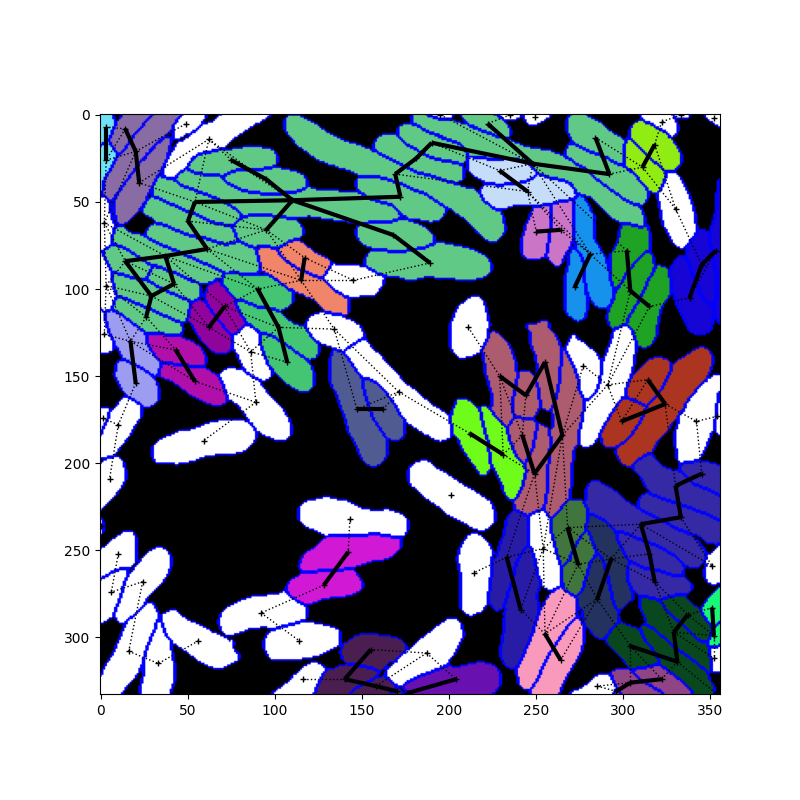

In [227]:
from detect_clusters import EdgeFilterAll, EdgeFilterAngleRatio, compute_clusters

L2 = LL[2]

rag2 = generate_graph(L2)

compute_clusters(rag2, min_cluster_size=2, edge_filter=EdgeFilterAngleRatio())

Lrgb = labels2rgb(L2.astype(int))

KT = rag_attribute_image(L2, rag2, 'trackid').astype(int)
KTrgb = labels2rgb(KT)

KC = rag_attribute_image(L2, rag2, 'cluster').astype(int)
KCrgb = labels2rgb(KC)

r = [0,L2.shape[1], L2.shape[1],0]

s = 8
vs = 1
fig,ax = plt.subplots(1,1,figsize=(s,s))
show_rag2(L2, rag2, KCrgb, img_cmap=None, ax=ax, border_color='blue', edge_width=3, edge_cmap='magma', 
          hide_zero=True, edge_filter=EdgeFilterAngleRatio(), show_filtered=True, ignore_node=0,
          velocity_back=True, velocity_scale=vs, arrow_config=dict(width=0.3, color='k'), )

### Convert all to RAG data structures for processing velocities and other attributes

TODO: convert image loading to multi-frame TIFF from the latest data from Danielle

In [ ]:
from detect_clusters import EdgeFilterAngleCountVelocity
from detect_clusters import rag_velocity_image, vel2rgb, show_rag2, EdgeFilterNone,xylim
from detect_clusters import generate_graph, trackidFromDPTrack, track_cells, detectAndTrackClusters
from detect_clusters import computeVelocities, computeAreaChange
from detect_clusters import labels2rgb, rag_attribute_image, rag_velocity_image
from skimage.io import imsave

# ASSUMES DATASET IS DEFINED
# indir, outdir, names, df, next_id

#outdir = '/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24_DynPack_track_clusters/'
#df = None

#edge_filter = EdgeFilterAngleCount(amax=15, count_min=30) 
edge_filter = EdgeFilterAngleCountVelocity(amax=15, count_min=30, vdiffmax=10)

for subdir in [ 'id_rgb', 'trackid', 'trackid_rgb', 
                'clustertrack', 'clustertrack_rgb', 
                'velocity_back_rgb', 'velocity_back_arrows', 'area_change_back' ]:
  os.makedirs( join(outdir, subdir), exist_ok=True)

L2 = None;  rag2 = None
next_id = None
next_cid = None
#for i in range(4):
for i in range(len(names)):
  L1 = L2;   rag1 = rag2

  name = names[i]
  inputfile = join(indir,name)
  print(inputfile)
  L2 = imread(inputfile)

  # PROCESSING

  ## 1. RAG graph
  rag2 = generate_graph(L2)

  ## 2. trackid
  if (df is not None):
    df1 = df[df.frame==i]
    next_id = trackidFromDPTrack(rag2, df1, next_id=next_id)
  else: # Track ourselves
    next_id = track_cells(rag2, L2, rag1, L1, next_id=next_id)
    
  ## 3. node spatio-temporal properties
  computeVelocities(rag1, rag2)
  computeAreaChange(rag1, rag2)

  ## 4. clusters
  next_cid = detectAndTrackClusters(rag2, L2, rag1, L1, 
                                edge_filter = edge_filter,
                                cluster_metric='count',
                                cluster_thresh=1, 
                                next_cid=next_cid)

  # VISUALIZATIONS

  Lrgb = labels2rgb(L2.astype(int))
  KT = rag_attribute_image(L2, rag2, 'trackid').astype(int)
  KTrgb = labels2rgb(KT)
  KC = rag_attribute_image(L2, rag2, 'clustertrack').astype(int)
  KCrgb = labels2rgb(KC)

  vmax = 10

  V2 = rag_velocity_image(L2, rag2, 'velocity_back').astype(float)
  bg2 = rag_attribute_image(L2, rag2, 'id') == 0
  Vrgb2 = vel2rgb(V2, velocity_max = vmax)
  Vrgb2[bg2,:] = 0.5

  A = rag_attribute_image(L2, rag2, 'area_change_back')
  A = np.clip( A+0.5, 0,1 )
  Argb = plt.cm.bwr(A)
  Argb[bg2,:] = 0.5

  imsave(join(outdir,'id_rgb',f'{name}_id_rgb.png'), np.uint8(Lrgb*255.0))
  imsave(join(outdir,'trackid',f'{name}_trackid.png'), KT.astype(np.int16), check_contrast=False)
  imsave(join(outdir,'trackid_rgb',f'{name}_trackid_rgb.png'), np.uint8(KTrgb*255.0))
  imsave(join(outdir,'clustertrack',f'{name}_cluster.png'), KC.astype(np.int16), check_contrast=False)
  imsave(join(outdir,'clustertrack_rgb',f'{name}_clustertrack_rgb.png'), np.uint8(KCrgb*255.0))
  imsave(join(outdir,'velocity_back_rgb',f'{name}_velocity_back_rgb.png'), np.uint8(Vrgb2*255.0))
  imsave(join(outdir,'area_change_back',f'{name}area_change_back.png'), np.uint8(Argb*255.0))

  r = [0,L2.shape[1], L2.shape[1],0]

  s = 8
  vs = 1
  fig,ax = plt.subplots(1,1,figsize=(s,s))
  show_rag2(L2, rag2, Vrgb2, img_cmap=None, ax=ax, border_color='blue', edge_width=3, edge_cmap='magma', 
            hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0,
            velocity_back=True, velocity_scale=vs, arrow_config=dict(width=0.3, color='k'), )
  plt.title(f'{name} - vmax={vmax}, vscale={vs}')
  xylim(r)
  plt.tight_layout()
  plt.savefig( join(outdir,'velocity_back_arrows',f'{name}_velocity_back_arrows.pdf') )
  plt.savefig( join(outdir,'velocity_back_arrows',f'PNG_{name}_velocity_back_arrows.png') )
  plt.close(fig)

  # show_rag2 does not support cmap borders yet
  fig,ax = plt.subplots(1,1,figsize=(s,s))
  show_rag2(L2, rag2, Argb, img_cmap=None, ax=ax, node_feature='trackid', edge_width=3, edge_cmap='bwr', 
            hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0 )
  plt.title(f'{name} - area_change_back, clim=[-1,1] log2 scale')
  xylim(r)
  plt.tight_layout()
  plt.savefig( join(outdir,'area_change_back',f'LABEL_{name}_area_change_back.png') )
  plt.close(fig)

In [ ]:
K1 = rag_attribute_image(L1, rag1, 'trackid').astype(int)
K2 = rag_attribute_image(L2, rag2, 'trackid').astype(int)
K3 = rag_attribute_image(L3, rag3, 'trackid').astype(int)

Krgb1 = labels2rgb(K1)
Krgb2 = labels2rgb(K2)
Krgb3 = labels2rgb(K3)

fig,ax = plt.subplots(1,3,figsize=(12,4))
show_rag2(L1, rag1, Krgb1, img_cmap=None, ax=ax[0], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[0])
show_rag2(L2, rag2, Krgb2, img_cmap=None, ax=ax[1], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[1])
show_rag2(L3, rag3, Krgb3, img_cmap=None, ax=ax[2], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[2])

<Axes: >

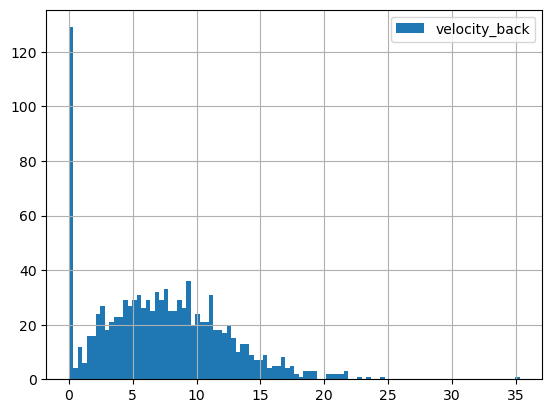

In [ ]:
#computeVelocities(rag1, rag2)
import pandas as pd
data = dict(rag2.nodes.data())
df = pd.DataFrame(data.values(), index=data.keys())
#df['velocity_back'].apply(lambda d: pd.Series(d, index=['vx','vy']))
df['velocity_back'].apply(lambda d: pd.Series(d, index=['vx','vy']))

vs = df['velocity_back'].apply(lambda d: np.linalg.vector_norm(d))
vs.hist(bins=100,legend='velocity')

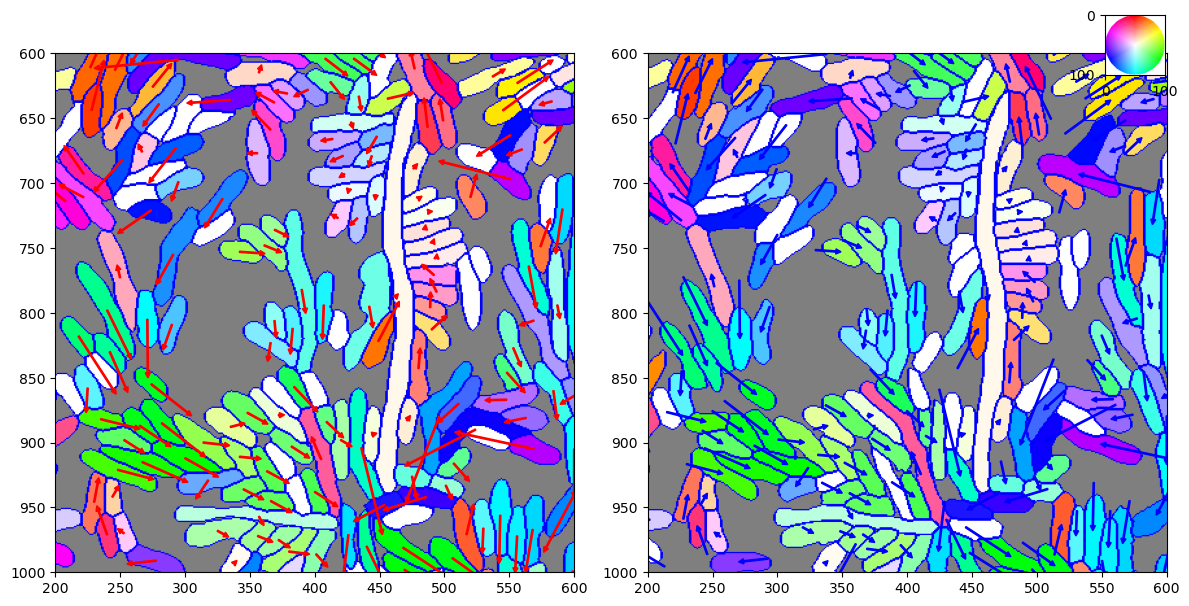

In [151]:
from detect_clusters import rag_velocity_image, vel2rgb, show_rag2, EdgeFilterNone,xylim
V = rag_velocity_image(L1, rag1, 'velocity_front').astype(float)
bg = rag_attribute_image(L1, rag1, 'id') == 0
Vrgb = vel2rgb(V, velocity_max = 10)
Vrgb[bg,:] = 0.5
#plt.imshow(Vrgb)

V2 = rag_velocity_image(L2, rag2, 'velocity_back').astype(float)
bg2 = rag_attribute_image(L2, rag2, 'id') == 0
Vrgb2 = vel2rgb(V2, velocity_max = 10)
Vrgb2[bg2,:] = 0.5

s=6
vs = 3
r = [200,600, 1000,600]

fig,ax = plt.subplots(1,2,figsize=(2*s,s))
show_rag2(L1, rag1, Vrgb, img_cmap=None, ax=ax[0], border_color='blue', velocity_front=True, velocity_scale=vs, edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[0])

show_rag2(L2, rag2, Vrgb2, img_cmap=None, ax=ax[1], border_color='blue', velocity_back=True, velocity_scale=vs, edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[1])

fig.tight_layout()

axhue = fig.add_axes( (0.9,0.9,0.1,0.1) )
xs = np.linspace(-1,1,101)
ys = np.linspace(-1,1,101)
Vlegend = vel2rgb(np.stack(np.meshgrid(ys,xs,indexing='ij'),axis=-1), clip_magnitude=False)
axhue.imshow(Vlegend)

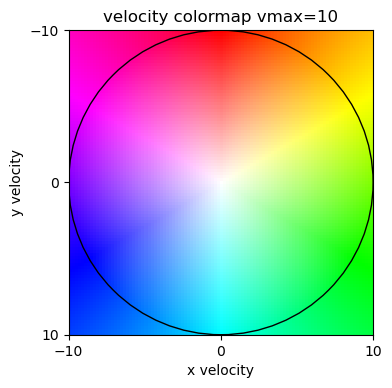

In [ ]:
import matplotlib


fig,ax = plt.subplots(1,1,figsize=(4,4))
vmax=10
xs = np.linspace(-1,1,101)
ys = np.linspace(-1,1,101)
Vlegend = vel2rgb(np.stack(np.meshgrid(ys,xs,indexing='ij'),axis=-1), clip_magnitude=True)
plt.imshow(Vlegend, extent=[-vmax,vmax,vmax,-vmax])
plt.xticks([-vmax,0,vmax])
plt.yticks([-vmax,0,vmax])
plt.xlabel('x velocity')
plt.ylabel('y velocity')
plt.title(f'velocity colormap vmax={vmax}')
ax.add_patch(matplotlib.patches.Circle((0,0),10, edgecolor='k',facecolor='#fff0'))
plt.tight_layout()
plt.savefig(join(outdir,'velocity_legend.png'))

# Napari tracking proof-of-concept

Install config env.yaml
```
laptrack
napari
```


In [9]:
from laptrack import LapTrack
from laptrack import datasets
from laptrack.data_conversion import convert_split_merge_df_to_napari_graph
from laptrack import OverLapTrack
import pandas as pd
from skimage.measure import regionprops_table
from skimage.io import imread
from os.path import join
import numpy as np

In [10]:
lt = LapTrack(cutoff=15**2, splitting_cutoff=30**2)
olt = OverLapTrack(
    cutoff=0.9,
    metric_coefs = (1.0, -1.0, -1.0, 0.0, 0.0),
    gap_closing_metric_coefs = (1.0, -1.0, 0.0, 0.0, 0.0),
    gap_closing_max_frame_count=1,
    splitting_cutoff=0.9,
    splitting_metric_coefs = (1.0, 0.0, 0.0, 0.0, -1.0),
    merging_cutoff=0.9,
    merging_metric_coefs = (1.0, 0.0, 0.0, -1.0, 0.0)

)

In [ ]:
# Toy dataset
#labels = datasets.mouse_epidermis()
#labels.shape

In [11]:
N = len(names)
N = 5

LL = []
for i in range(N):
  name = names[i]
  inputfile = join(indir,name)
  print(inputfile)
  L2 = imread(inputfile)
  LL.append(L2)
labels = np.stack(LL, axis=0)
labels.shape

/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24 Dynamic Pack Masks/7-3-24 dynamic packs-20000_cp_masks.png
/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24 Dynamic Pack Masks/7-3-24 dynamic packs-20001_cp_masks.png
/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24 Dynamic Pack Masks/7-3-24 dynamic packs-20002_cp_masks.png
/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24 Dynamic Pack Masks/7-3-24 dynamic packs-20003_cp_masks.png
/home/rmegret/PROBE/71024_Dynamic_Pack_Masks/7-10-24 Dynamic Pack Masks/7-3-24 dynamic packs-20004_cp_masks.png


(5, 1048, 1040)

In [138]:
labels = np.zeros( (3,128,128), dtype=int )
labels[0, 30:40,5:25] = 101
labels[0, 30:40,50:100] = 102
labels[0, 60:70,50:60] = 200
labels[0, 60:70,70:80] = 201

labels[1, 30:40,5:14] = 103
labels[1, 30:40,16:25] = 104
labels[1, 30:40,50:60] = 105
labels[1, 30:40,65:85] = 106
labels[1, 30:40,90:100] = 107
labels[1, 60:70,50:80] = 202

labels[2, 30:40,5:25] = 10
labels[2, 30:40,50:60] = 11
labels[2, 30:40,65:100] = 12


In [12]:
track_df, split_df, merge_df = olt.predict_overlap_dataframe(labels)
track_df.shape, split_df.shape, merge_df.shape

((5387, 2), (164, 2), (174, 2))

Memo: 45s for 5 frames, 5387 items

### Deal with split and merge events

In [13]:
dfs = []
for frame in range(len(labels)):
    df = pd.DataFrame(
        regionprops_table(labels[frame], properties=["label", "centroid"])
    )
    df["frame"] = frame
    dfs.append(df)
coordinate_df = pd.concat(dfs).set_index(["frame", "label"])
track_df2 = pd.merge(
    track_df, coordinate_df, right_index=True, left_index=True
).reset_index()
display(track_df2.head())
track_df2

split_parent = split_df.set_index('child_track_id')['parent_track_id'].to_dict()
print(split_parent)
split_children = split_df.groupby('parent_track_id')['child_track_id'].agg(list).to_dict()
print(split_children)
merge_child = merge_df.set_index('parent_track_id')['child_track_id'].to_dict()
print(merge_child)
merge_parents = merge_df.groupby('child_track_id')['parent_track_id'].agg(list).to_dict()
print(merge_parents)

trackframes_df = track_df2.groupby('track_id').agg({'frame': ['min', 'max']})
trackframes_df.columns = [f"{col[0]}_{col[1]}" for col in trackframes_df.columns]
trackframes_df
track_frame_start = trackframes_df['frame_min'].to_dict()
track_frame_end = trackframes_df['frame_max'].to_dict()
track_frame_start, track_frame_end

None


,frame,label,tree_id,track_id,centroid-0,centroid-1
0,0,1,0,0,5.630719,101.872549
1,0,2,1,1,5.952941,138.511765
2,0,3,2,2,15.629534,261.406736
3,0,4,3,3,4.300885,313.831858
4,0,5,4,4,4.330435,341.347826


{1077: 1, 1070: 1, 1073: 11, 1078: 11, 1086: 164, 1083: 164, 1088: 199, 1087: 199, 1092: 377, 1093: 377, 1096: 459, 1097: 459, 1155: 482, 1156: 482, 1107: 644, 1110: 644, 1111: 656, 1116: 656, 1112: 669, 1113: 669, 1127: 679, 1114: 679, 1118: 719, 1117: 719, 1120: 735, 1119: 735, 1121: 747, 1158: 747, 1157: 749, 1123: 749, 1122: 765, 1140: 765, 1132: 858, 1130: 858, 1134: 896, 1152: 896, 1139: 924, 1136: 924, 1142: 953, 1141: 953, 1146: 1015, 1147: 1015, 1145: 1020, 1151: 1020, 1080: 1030, 1081: 1030, 1079: 1032, 1082: 1032, 1076: 1034, 1075: 1034, 1098: 1064, 1100: 1064, 1169: 144, 1168: 144, 1173: 234, 1175: 234, 1179: 1090, 1174: 1090, 1176: 255, 1177: 255, 1234: 1065, 1235: 1065, 1181: 375, 1182: 375, 1184: 415, 1186: 415, 1195: 475, 1192: 475, 1190: 1099, 1189: 1099, 1193: 512, 1194: 512, 1198: 578, 1202: 578, 1208: 663, 1207: 663, 1204: 690, 1206: 690, 1213: 1122, 1225: 1122, 1216: 799, 1215: 799, 1217: 1039, 1218: 1039, 1221: 1038, 1223: 1038, 1219: 1132, 1220: 1132, 1222: 885, 

In [14]:
f1 = 0
f2 = 1

rag1 = generate_graph(labels[f1])
rag2 = generate_graph(labels[f2])

In [15]:
split_df0 = split_df.set_index('child_track_id')

for _,item in track_df2[track_df2.frame==f1].iterrows():
  rag1.nodes[item.label]['trackid'] = int(item.track_id)
  if (track_frame_start[item.track_id] == f1): 
    rag1.nodes[item.label]['merge_parents'] = merge_parents.get(item.track_id,[])
    rag1.nodes[item.label]['split_parent'] = split_parent.get(item.track_id,None)
  if (track_frame_end[item.track_id] == f1): 
    rag1.nodes[item.label]['split_children'] = split_children.get(item.track_id,[])
    rag1.nodes[item.label]['merge_child'] = merge_child.get(item.track_id,None)

for _,item in track_df2[track_df2.frame==f2].iterrows():
  rag2.nodes[item.label]['trackid'] = int(item.track_id)
  if (track_frame_start[item.track_id] == f2): 
    rag2.nodes[item.label]['merge_parents'] = merge_parents.get(item.track_id,[])
    rag2.nodes[item.label]['split_parent'] = split_parent.get(item.track_id,None)
  if (track_frame_end[item.track_id] == f2): 
    rag2.nodes[item.label]['split_children'] = split_children.get(item.track_id,[])
    rag2.nodes[item.label]['merge_child'] = merge_child.get(item.track_id,None)

In [185]:
rag1.nodes.get(1077)

In [16]:
for _,item in track_df2[track_df2.frame==f1].iterrows():
  rag1.nodes[item.label]['trackid'] = int(item.tree_id+1)
for _,item in track_df2[track_df2.frame==f2].iterrows():
  rag2.nodes[item.label]['trackid'] = int(item.tree_id+1)

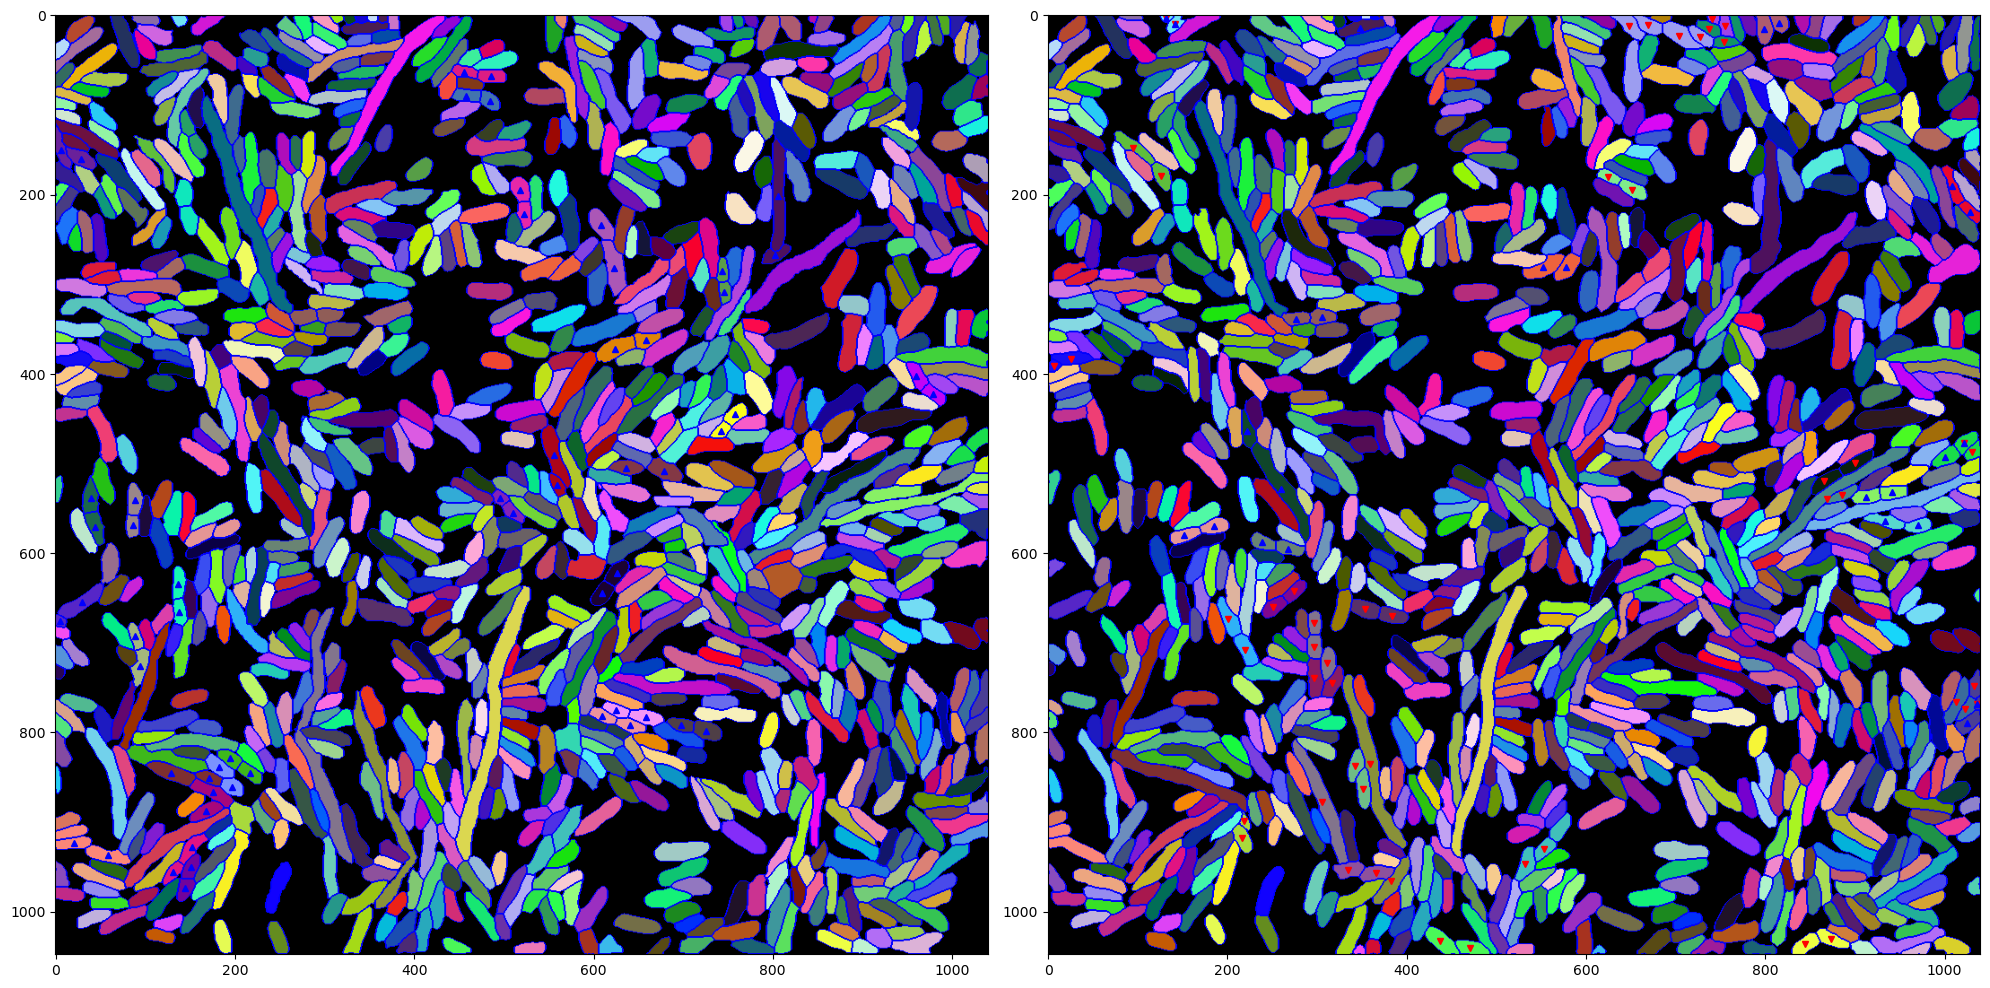

In [17]:
from detect_clusters import rag_velocity_image, vel2rgb, show_rag2, EdgeFilterNone,xylim

L1 = labels[f1]
L2 = labels[f2]

K1 = labels2rgb(L1)
K2 = labels2rgb(L2)

T1 = labels2rgb(rag_attribute_image(L1, rag1, 'trackid').astype(int))
T2 = labels2rgb(rag_attribute_image(L2, rag2, 'trackid').astype(int))

s=10
vs = 3
r = [200,600, 1000,600]

fig,ax = plt.subplots(1,2,figsize=(2*s,s))
show_rag2(L1, rag1, T1, img_cmap=None, ax=ax[0], node_feature='split_merge_indicator', border_color='blue', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
#xylim(r, ax[0])

show_rag2(L2, rag2, T2, img_cmap=None, ax=ax[1], node_feature='split_merge_indicator', border_color='blue', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
#xylim(r, ax[1])

fig.tight_layout()

## Napari viewer

In [10]:
from dotenv import load_dotenv

load_dotenv()

True

In [11]:
!echo PWD=$PWD
!echo DISPLAY=$DISPLAY
!echo LIBGL_ALWAYS_INDIRECT=$LIBGL_ALWAYS_INDIRECT
!echo LIBGL_ALWAYS_SOFTWARE=$LIBGL_ALWAYS_SOFTWARE

PWD=/home/rmegret/PROBE/cell_track_analysis
DISPLAY=192.168.0.14:0
LIBGL_ALWAYS_INDIRECT=0
LIBGL_ALWAYS_SOFTWARE=1


In [12]:
import napari

viewer = napari.Viewer()
#viewer.add_labels(labels)
napari.run()

In [13]:
viewer.add_labels(labels, name="labels")

<Labels layer 'labels' at 0x7ff0b641f100>

In [19]:
track_label_image = np.zeros_like(labels)
for (frame, label), row in track_df.iterrows():
    track_label_image[frame][labels[frame] == label] = row["track_id"] + 1

viewer.layers["labels"].visible = False
viewer.add_labels(track_label_image)

<Labels layer 'track_label_image [1]' at 0x7ff0b7251870>

In [20]:
graph = convert_split_merge_df_to_napari_graph(split_df, merge_df)
viewer.add_tracks(
    track_df2[["track_id", "frame", "centroid-0", "centroid-1"]].values,
    graph=graph,
    tail_length=1,
)

<Tracks layer 'Tracks' at 0x7ff0f1c1eef0>

: 

In [ ]:
K1 = rag_attribute_image(L1, rag1, 'trackid').astype(int)
K2 = rag_attribute_image(L2, rag2, 'trackid').astype(int)
Vrgb = rag_attribute_image(L1, rag1, 'velocity_front', mode='velocity', velocity_max=5.0).astype(float)

Krgb1 = labels2rgb(K1)
Krgb2 = labels2rgb(K2)

fig,ax = plt.subplots(1,3,figsize=(12,4))
show_rag2(L1, rag1, Krgb1, img_cmap=None, ax=ax[0], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[0])
show_rag2(L2, rag2, Krgb2, img_cmap=None, ax=ax[1], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[1])
show_rag2(L1, rag1, Vrgb, img_cmap=None, ax=ax[2], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[2])

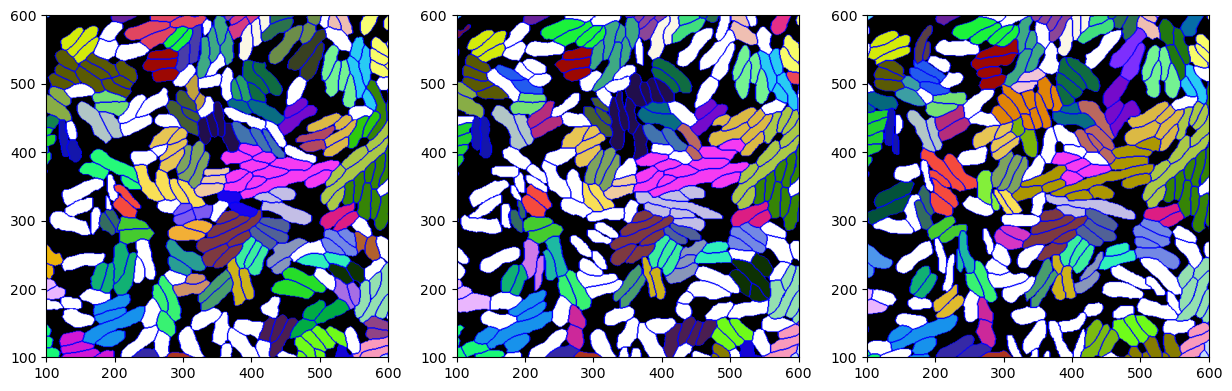

In [258]:
K1 = rag_attribute_image(L1, rag1, 'clustertrack').astype(int)
K2 = rag_attribute_image(L2, rag2, 'clustertrack').astype(int)
K3 = rag_attribute_image(L3, rag3, 'clustertrack').astype(int)

Krgb1 = labels2rgb(K1)
Krgb2 = labels2rgb(K2)
Krgb3 = labels2rgb(K3)

r = [100,600, 100,600]
s = 5

fig,ax = plt.subplots(1,3,figsize=(3*s,s))
show_rag2(L1, rag1, Krgb1, img_cmap=None, ax=ax[0], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[0])
show_rag2(L2, rag2, Krgb2, img_cmap=None, ax=ax[1], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[1])
show_rag2(L3, rag3, Krgb3, img_cmap=None, ax=ax[2], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[2])

In [ ]:
n1 = int(L1.max())+1
map1toT = np.zeros( (n1,), dtype=int )
for u in rag1.nodes:
  node = rag1.nodes[u]
  map1toT[node['id']] = node['trackid']
L1T = map1toT[L1]

show_rag2(L1T, rag3, Krgb3, img_cmap=None, ax=ax[2], border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=EdgeFilterNone(), show_filtered=False, ignore_node=0)
xylim(r, ax[2])

In [267]:
!mkdir -p bacteriamasks4/cc_rgb/ bacteriamasks4/cc_rgbb/ bacteriamasks4/cc/

In [295]:
folder='bacteriamasks0'

In [300]:
!mkdir -p {folder}/cc_rgb/ {folder}/cc_rgbb/ {folder}/cc/ {folder}/Lrgb/

In [302]:
from skimage.io import imsave

for kk in range(len(filenames)):
  f = filenames[kk]
  n = ns[kk]
  print(f, n)

  L = imread(f)

  outname = f'{folder}/cc/cc_wbeads000{n}_cp_clusters.tiff'
  rgbname = f'{folder}/cc_rgb/cc_rgb_wbeads000{n}_cp_rgbclusters.png'
  rgbbname = f'{folder}/cc_rgbb/cc_rgbb_wbeads000{n}_cp_rgbclusters.png'
  LRGBname = f'{folder}/Lrgb/Lrgb_wbeads000{n}_cp.png'

  print(f,outname,rgbname)
  
  rag = skimage.graph.rag_boundary(L, np.ones_like(L,dtype=np.float32))
  augment_graph(rag, L)
  compute_clusters(rag, min_cluster_size=3, edge_filter=edge_filter0)

  LRGB = labels2rgb(L)
  imsave(LRGBname, np.uint8(LRGB*255.0))

  LC = rag_attribute_image(L, rag, 'cluster').astype(np.int16)
  LCRGB = labels2rgb(LC)

  imsave(outname, LC)
  imsave(rgbname, np.uint8(LCRGB*255.0))

  LCRGB_boundaries = segmentation.mark_boundaries(LCRGB, L, color=[0,0,1.0])
  imsave(rgbbname, np.uint8(LCRGB_boundaries*255.0))

  

bacteriamasks/wbeads0000_cp_masks.png 0
bacteriamasks/wbeads0000_cp_masks.png bacteriamasks0/cc/cc_wbeads0000_cp_clusters.tiff bacteriamasks0/cc_rgb/cc_rgb_wbeads0000_cp_rgbclusters.png


/tmp/ipykernel_479/1983881363.py:27: UserWarning: bacteriamasks0/cc/cc_wbeads0000_cp_clusters.tiff is a low contrast image
  imsave(outname, LC)


bacteriamasks/wbeads0001_cp_masks.png 1
bacteriamasks/wbeads0001_cp_masks.png bacteriamasks0/cc/cc_wbeads0001_cp_clusters.tiff bacteriamasks0/cc_rgb/cc_rgb_wbeads0001_cp_rgbclusters.png


/tmp/ipykernel_479/1983881363.py:27: UserWarning: bacteriamasks0/cc/cc_wbeads0001_cp_clusters.tiff is a low contrast image
  imsave(outname, LC)


bacteriamasks/wbeads0002_cp_masks.png 2
bacteriamasks/wbeads0002_cp_masks.png bacteriamasks0/cc/cc_wbeads0002_cp_clusters.tiff bacteriamasks0/cc_rgb/cc_rgb_wbeads0002_cp_rgbclusters.png


...

/tmp/ipykernel_479/1983881363.py:27: UserWarning: bacteriamasks0/cc/cc_wbeads0007_cp_clusters.tiff is a low contrast image
  imsave(outname, LC)


bacteriamasks/wbeads0008_cp_masks.png 8
bacteriamasks/wbeads0008_cp_masks.png bacteriamasks0/cc/cc_wbeads0008_cp_clusters.tiff bacteriamasks0/cc_rgb/cc_rgb_wbeads0008_cp_rgbclusters.png


/tmp/ipykernel_479/1983881363.py:27: UserWarning: bacteriamasks0/cc/cc_wbeads0008_cp_clusters.tiff is a low contrast image
  imsave(outname, LC)


bacteriamasks/wbeads0009_cp_masks.png 9
bacteriamasks/wbeads0009_cp_masks.png bacteriamasks0/cc/cc_wbeads0009_cp_clusters.tiff bacteriamasks0/cc_rgb/cc_rgb_wbeads0009_cp_rgbclusters.png


/tmp/ipykernel_479/1983881363.py:27: UserWarning: bacteriamasks0/cc/cc_wbeads0009_cp_clusters.tiff is a low contrast image
  imsave(outname, LC)


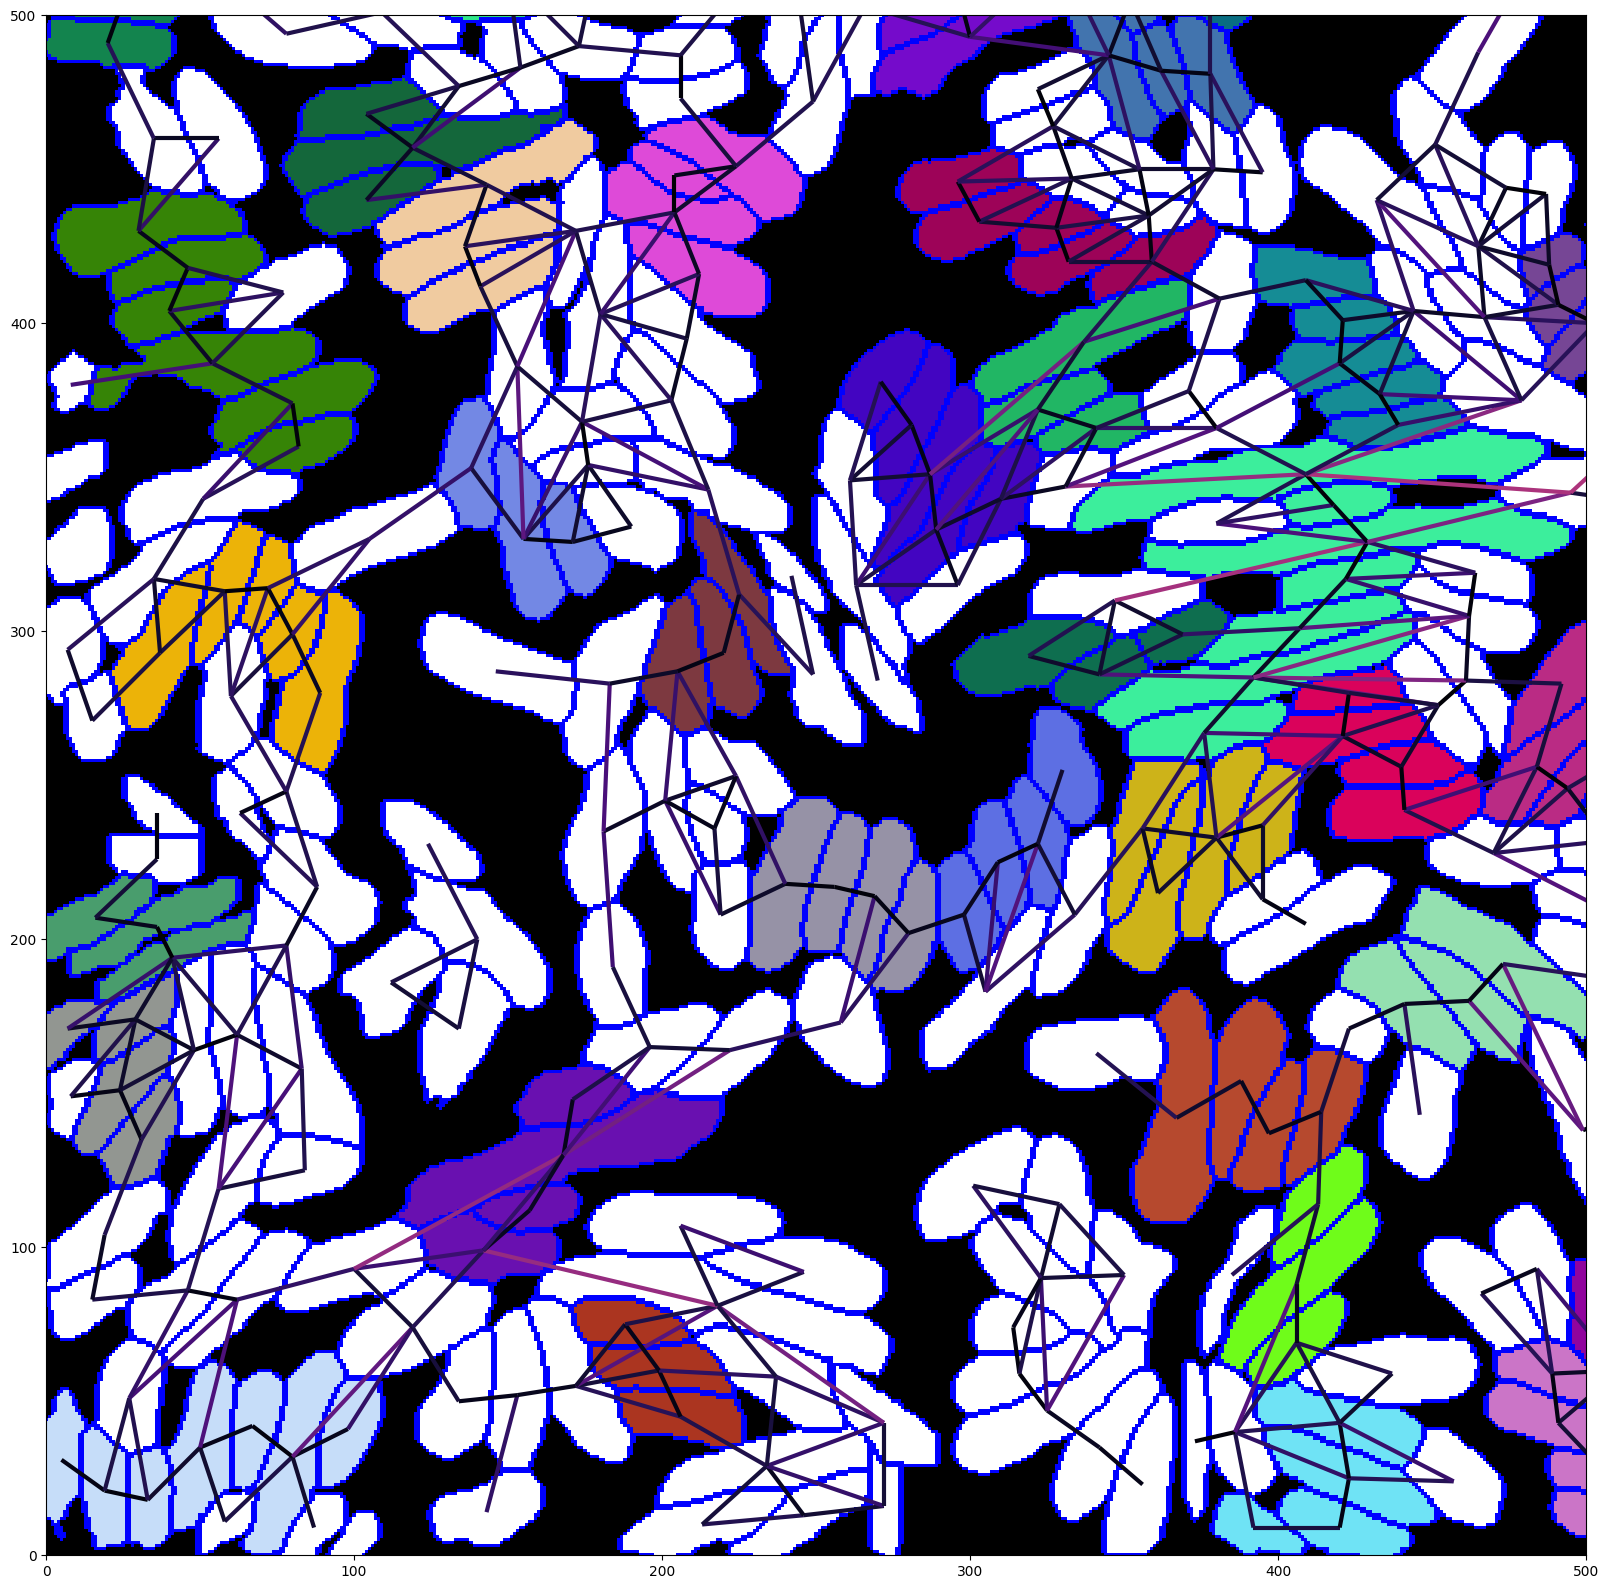

In [279]:
#Lrgb = labels2rgb(L)
Lcluster = labels2rgb(map_attribute(L, rag, 'cluster').astype(int))

fig,ax = plt.subplots(1,1,figsize=(20,20))
show_rag2(L, rag, Lcluster, img_cmap=None, ax=ax, border_color='blue', dataname='centroid_distance', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=None, show_filtered=False, ignore_node=0)
rg = (0,500,0,500)
xylim(rg)
plt.savefig('raw_graph_a15_cd30.png')

In [285]:
L.shape

(1048, 1040)

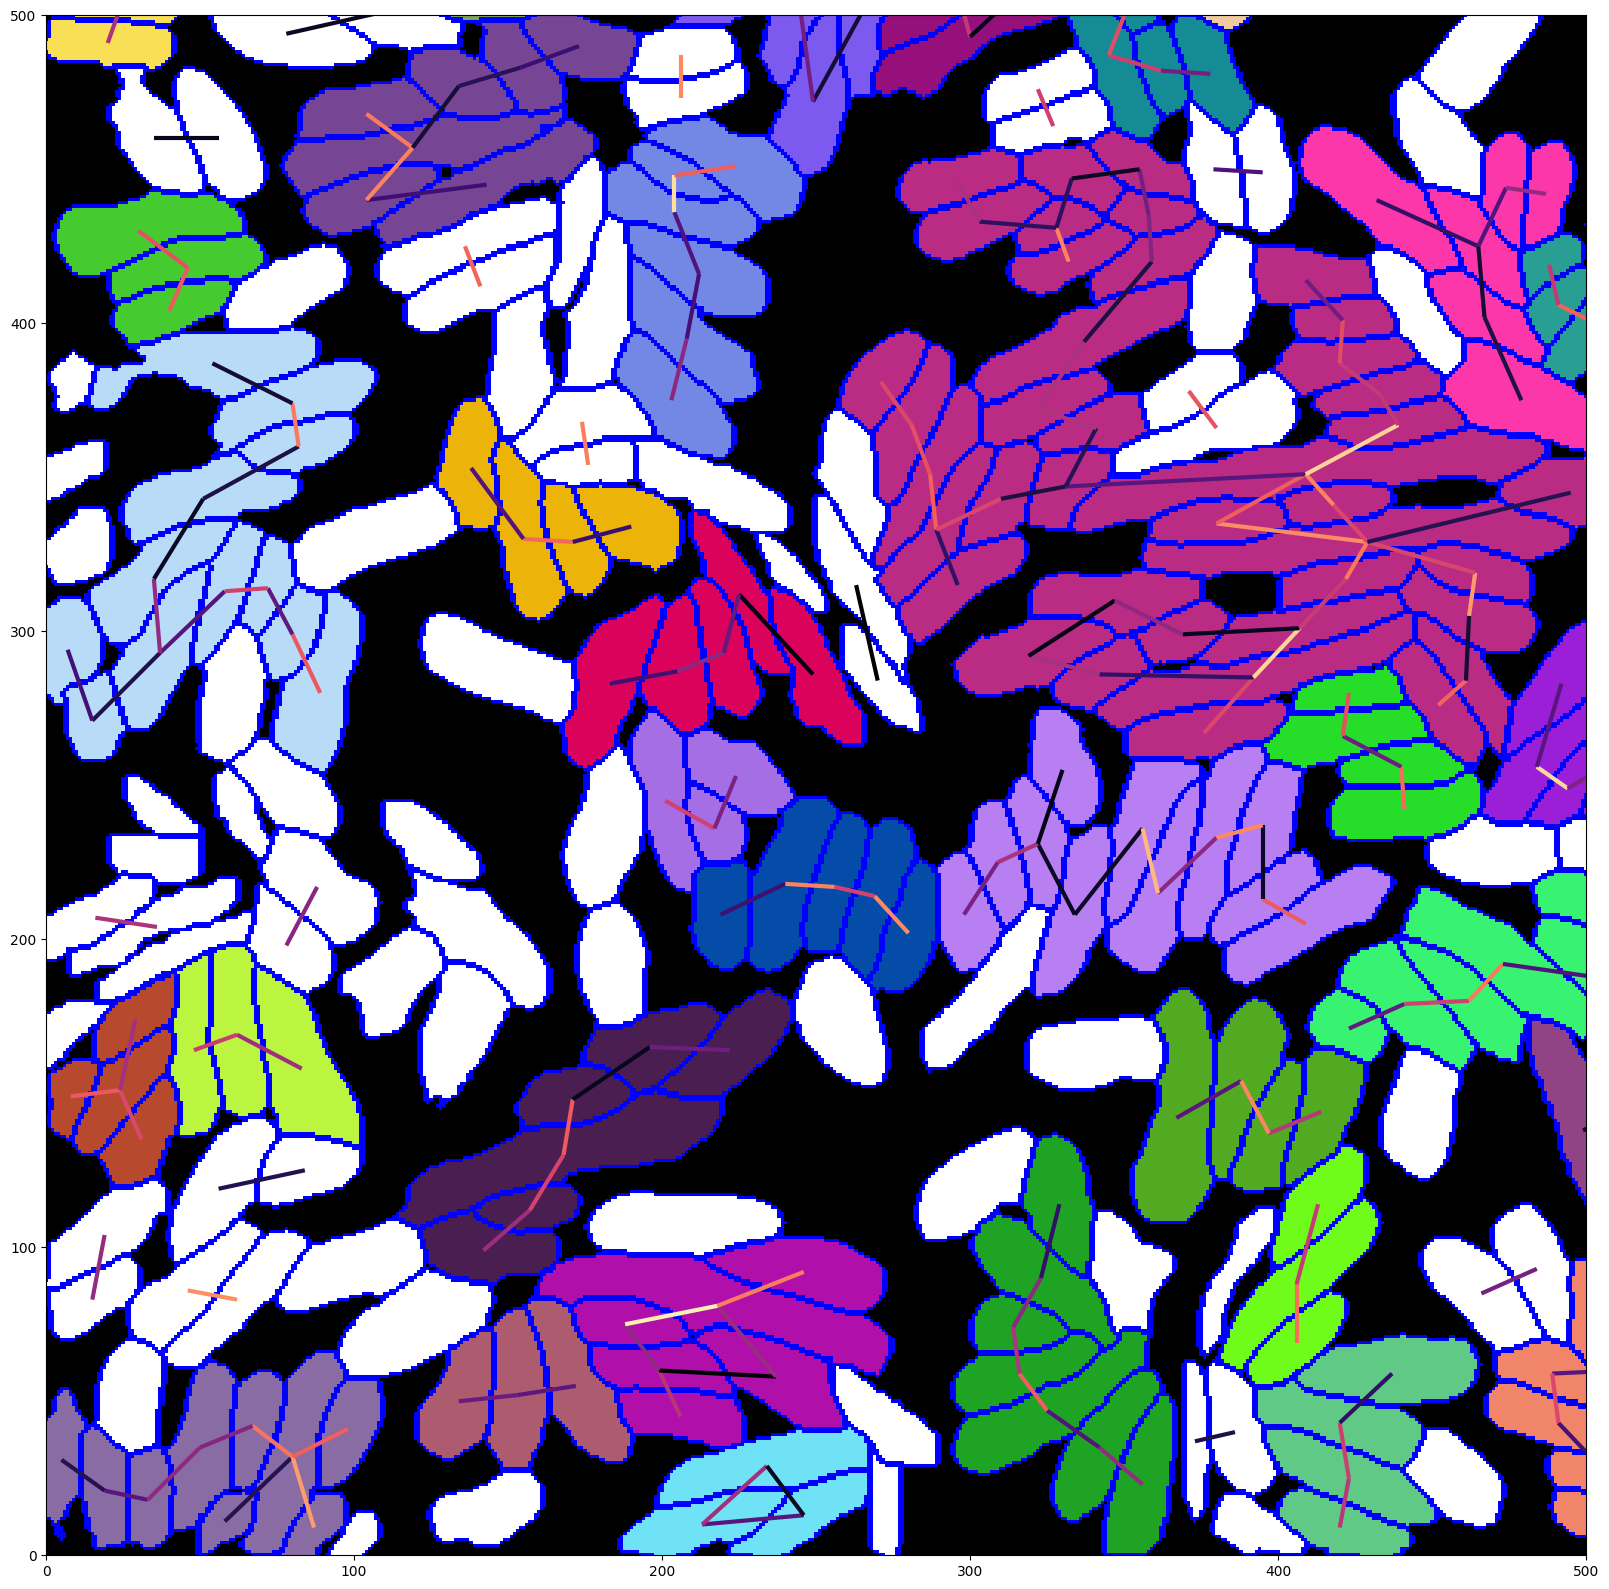

In [293]:
def edge_filter0(rag, u, v, amax=45, mcmin=0.20):
  return ( (rag.get_edge_data(u,v)['relative_angle']<=amax) \
      and (rag.get_edge_data(u,v)['max_count_ratio']>=mcmin) )

rag = skimage.graph.rag_boundary(L, np.ones_like(L,dtype=np.float32))
augment_graph(rag, L)
compute_clusters(rag, min_cluster_size=3, edge_filter=edge_filter0)

LC = map_attribute(L, rag, 'cluster').astype(np.int16)
LCRGB = labels2rgb(LC)

#Lrgb = labels2rgb(L)
Lcluster = labels2rgb(map_attribute(L, rag, 'cluster').astype(int))

fig,ax = plt.subplots(1,1,figsize=(20,20))
show_rag2(L, rag, Lcluster, img_cmap=None, ax=ax, border_color='blue', dataname='max_count_ratio', edge_width=3, edge_cmap='magma', hide_zero=True, edge_filter=edge_filter0, show_filtered=False, ignore_node=0)
rg = (0,500,0,500)
xylim(rg)
plt.savefig('pruned_graph_a45_mc0.20.png')

In [233]:
df = to_pandas_nodelist(rag)
df = df[df.cluster>0].copy()

In [234]:
df

,labels,area,angle,centroid,boundary_count,cluster
7,[7],586.0,-1.258973,"[9.448805460750853, 420.3754266211604]",245,2
8,[8],432.0,-0.143083,"[15.034722222222221, 807.0879629629629]",155,3
10,[10],563.0,-0.013226,"[17.05328596802842, 823.7388987566608]",222,3
11,[11],367.0,0.796472,"[10.425068119891009, 887.3569482288829]",191,4
13,[13],467.0,-1.176955,"[11.618843683083512, 988.1070663811563]",274,5
...,...,...,...,...,...,...
1139,[1139],502.0,-1.505174,"[1039.9262948207172, 658.3366533864541]",236,249
341,[341],690.0,0.573147,"[333.4405797101449, 289.7217391304348]",367,71
405,[405],511.0,-0.602894,"[384.79843444227004, 963.7455968688845]",251,74
624,[624],428.0,1.066319,"[570.6355140186915, 772.4415887850467]",224,136


In [236]:
H = compute_clusters(rag, min_cluster_size=3, edge_filter=edge_filter4)

In [241]:
df = nx.to_pandas_edgelist(H)
df

,source,target,count,relative_angle,centroid_distance,weight,max_count_ratio
0,4,44,100,3.990150,27.744145,1.0,0.330033
1,7,17,41,6.439503,28.118086,1.0,0.196172
2,7,38,85,7.008135,16.208022,1.0,0.346939
3,38,54,118,8.912963,17.907330,1.0,0.359756
4,8,10,30,7.440239,16.772843,1.0,0.193548
...,...,...,...,...,...,...,...
542,1129,1137,67,6.017271,12.704859,1.0,0.345361
543,1114,1122,105,2.538594,17.030590,1.0,0.368421
544,1122,1134,116,0.093402,14.549922,1.0,0.379085
545,1134,1139,69,7.653990,28.409704,1.0,0.292373


In [ ]:
LCRGB_boundaries = segmentation.mark_boundaries(LCRGB, L, color=[0,0,255])
plt.imshow(LCRGB_boundaries)
xylim( rg )

# Analysis of cluster properties

Text(0, 0.5, 'centroid distance')

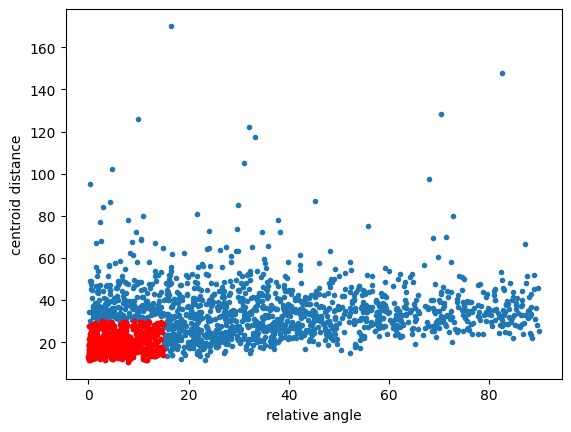

In [258]:
df = nx.to_pandas_edgelist(rag)

H = compute_clusters(rag, min_cluster_size=3, edge_filter=edge_filter4)
df2 = nx.to_pandas_edgelist(H)

df = df[ (df.source!=0)&(df.target!=0) ]
df2 = df2[ (df2.source!=0)&(df2.target!=0) ]

plt.plot( df['relative_angle'], df['centroid_distance'], '.' )
plt.plot( df2['relative_angle'], df2['centroid_distance'], 'r.' )
plt.xlabel('relative angle')
plt.ylabel('centroid distance')

Text(0, 0.5, 'common boundary count')

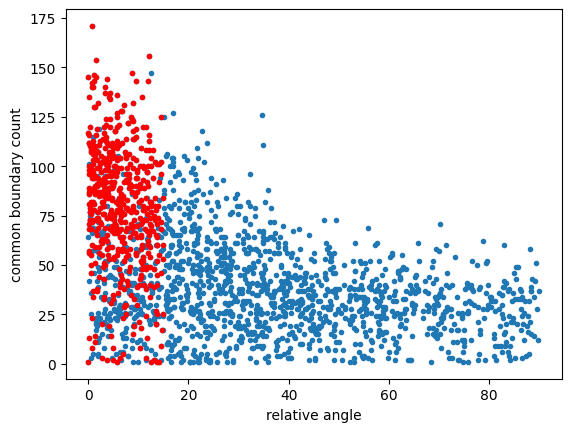

In [259]:
plt.plot( df['relative_angle'], df['count'], '.' )
plt.plot( df2['relative_angle'], df2['count'], 'r.' )
plt.xlabel('relative angle')
plt.ylabel('common boundary count')

# Interactive plots

In [6]:
from dash import Dash, dcc, html, Input, Output, callback

import plotly.express as px

import json
import pandas as pd

In [14]:
P = regionprops(L)

labels = np.array([p.label for p in P])
C = np.array([p.centroid for p in P])
angle = np.array([p.orientation for p in P])
area = np.array([p.area for p in P])

In [16]:
df = pd.DataFrame()
df['x'] = C[:,0]
df['y'] = C[:,1]
df['angle'] = angle
df['area'] = area

fig = px.imshow(L)
fig2 = px.scatter(df, x="x", y="y", color="area", custom_data=["angle"])

fig2.show()

In [41]:
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']

app = Dash(__name__, external_stylesheets=external_stylesheets)

styles = {
    'pre': {
        'border': 'thin lightgrey solid',
        'overflowX': 'scroll'
    }
}

df = pd.DataFrame({
    "x": [1,2,1,2],
    "y": [1,2,3,4],
    "customdata": [1,2,3,4],
    "fruit": ["apple", "apple", "orange", "orange"]
})

fig = px.scatter(df, x="x", y="y", color="fruit", custom_data=["customdata"])

fig.update_layout(clickmode='event+select')

fig.update_traces(marker_size=20)

app.layout = html.Div([
    dcc.Graph(
        id='basic-interactions',
        figure=fig
    ),

    html.Div(className='row', children=[
        html.Div([
            dcc.Markdown("""
                **Hover Data**

                Mouse over values in the graph.
            """),
            html.Pre(id='hover-data', style=styles['pre'])
        ], className='three columns'),

        html.Div([
            dcc.Markdown("""
                **Click Data**

                Click on points in the graph.
            """),
            html.Pre(id='click-data', style=styles['pre']),
        ], className='three columns'),

        html.Div([
            dcc.Markdown("""
                **Selection Data**

                Choose the lasso or rectangle tool in the graph's menu
                bar and then select points in the graph.

                Note that if `layout.clickmode = 'event+select'`, selection data also
                accumulates (or un-accumulates) selected data if you hold down the shift
                button while clicking.
            """),
            html.Pre(id='selected-data', style=styles['pre']),
        ], className='three columns'),

        html.Div([
            dcc.Markdown("""
                **Zoom and Relayout Data**

                Click and drag on the graph to zoom or click on the zoom
                buttons in the graph's menu bar.
                Clicking on legend items will also fire
                this event.
            """),
            html.Pre(id='relayout-data', style=styles['pre']),
        ], className='three columns')
    ])
])


@callback(
    Output('hover-data', 'children'),
    Input('basic-interactions', 'hoverData'))
def display_hover_data(hoverData):
    return json.dumps(hoverData, indent=2)


@callback(
    Output('click-data', 'children'),
    Input('basic-interactions', 'clickData'))
def display_click_data(clickData):
    return json.dumps(clickData, indent=2)


@callback(
    Output('selected-data', 'children'),
    Input('basic-interactions', 'selectedData'))
def display_selected_data(selectedData):
    return json.dumps(selectedData, indent=2)


@callback(
    Output('relayout-data', 'children'),
    Input('basic-interactions', 'relayoutData'))
def display_relayout_data(relayoutData):
    return json.dumps(relayoutData, indent=2)


In [42]:
app.run(debug=True)

In [ ]:
import napari

napari.run()